### 1. Setup and Data Preparation
We will use the CIFAR-10 dataset, which contains 60,000 32x32 color images in 10 classes.

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, matthews_corrcoef, roc_curve, auc, precision_recall_curve, average_precision_score
import seaborn as sns
import cv2

# Check GPU
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  print('GPU device not found. Running on CPU (slow).')
else:
  print('Found GPU at: {}'.format(device_name))

# Load Fashion MNIST data
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Expand dimensions because CNNs expect (batch, height, width, channels)
x_train = np.expand_dims(x_train, -1) / 255.0
x_test = np.expand_dims(x_test, -1) / 255.0

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

Found GPU at: /device:GPU:0
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


### 2. Define and Visualize CNN Architecture
We build a CNN and use `visualkeras` or the built-in `plot_model` for layer-wise visualization.

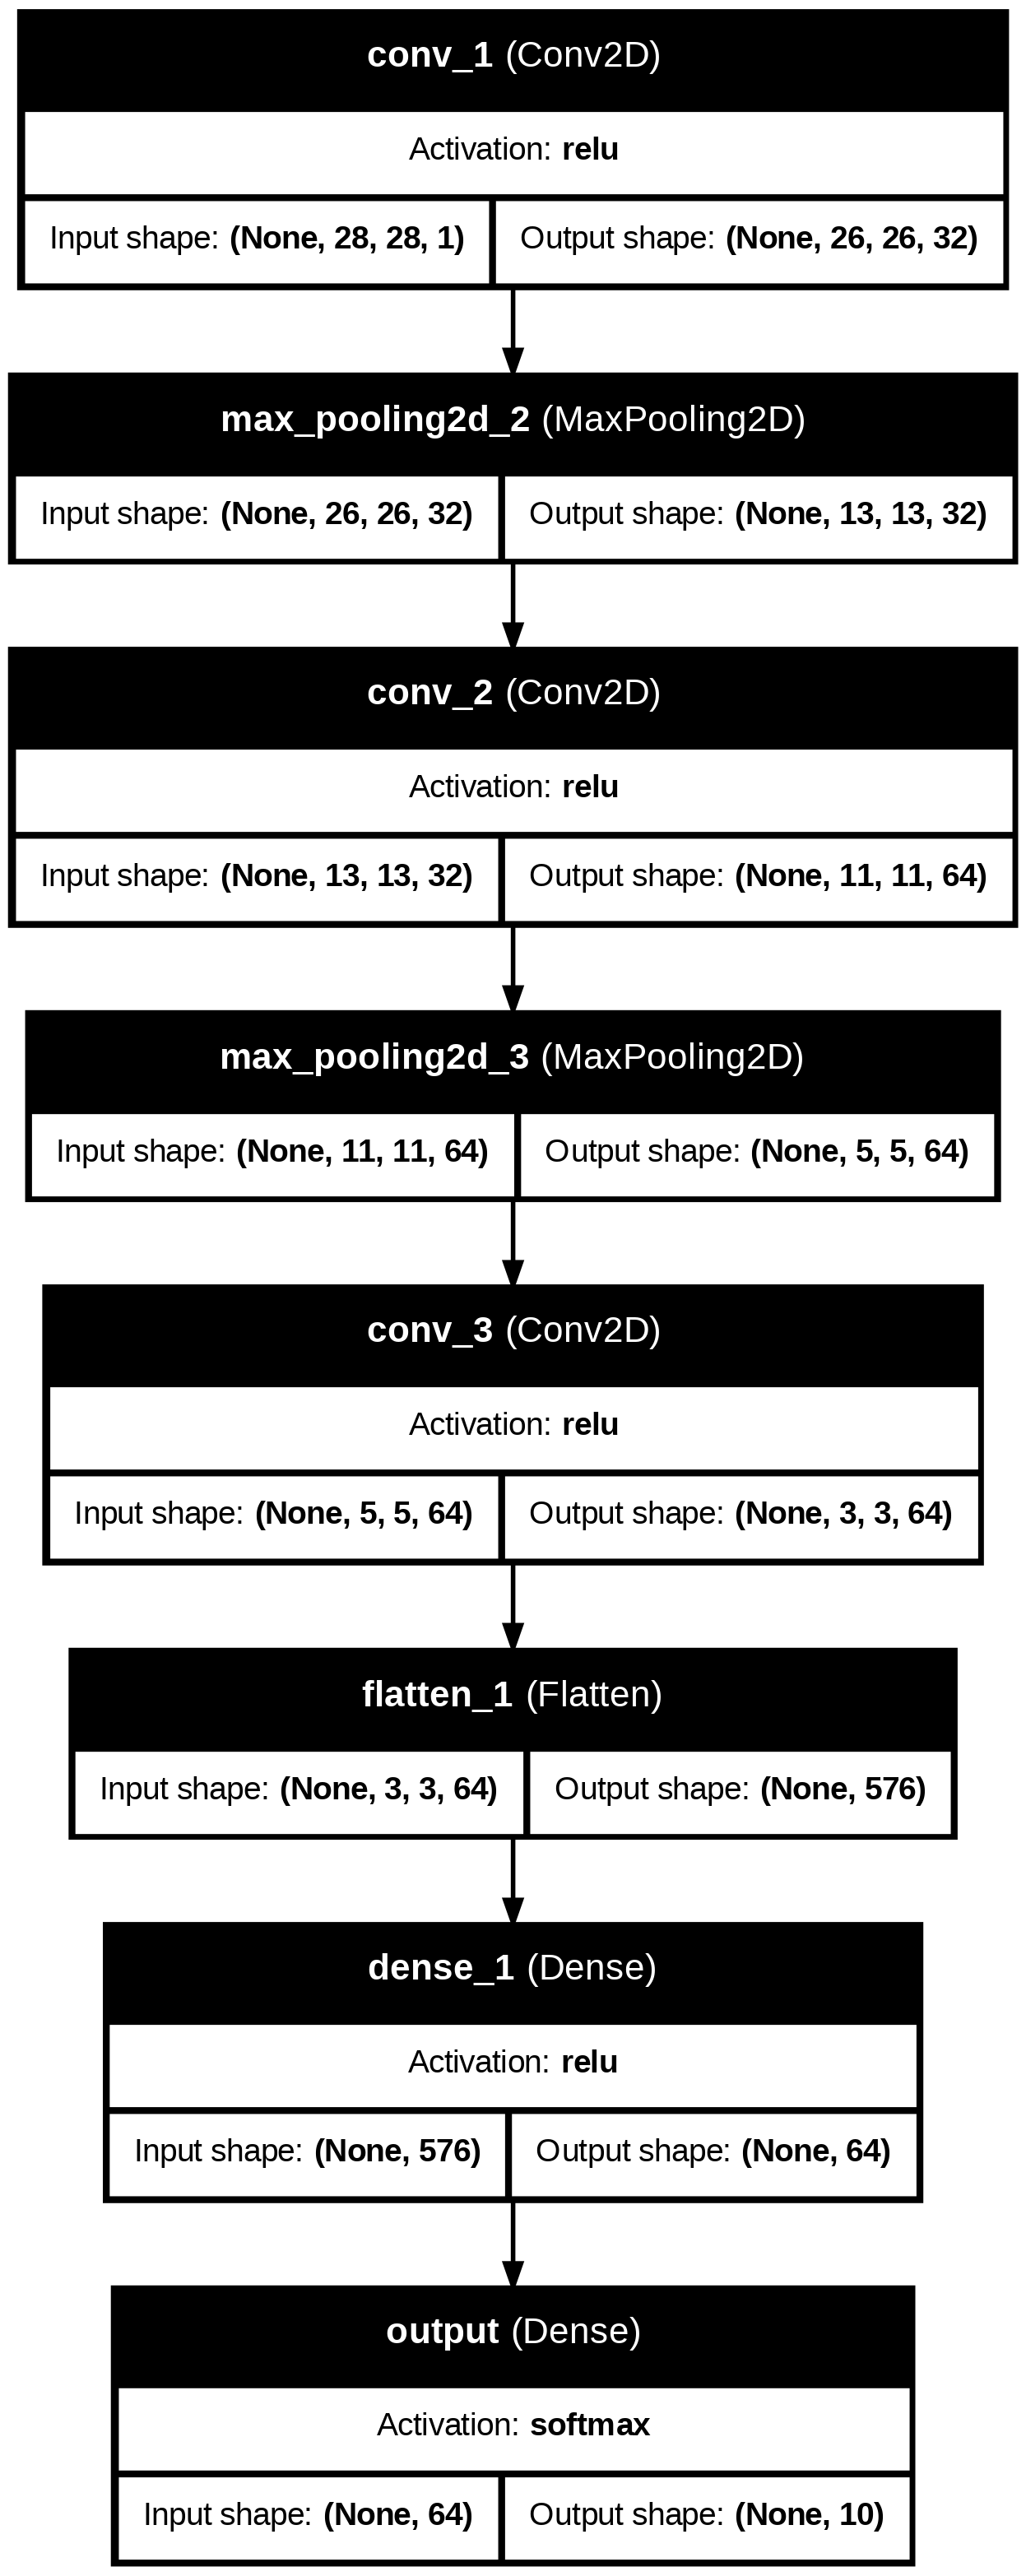

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models

def create_model():
    model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, (3, 3), activation='relu', name='conv_1'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu', name='conv_2'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu', name='conv_3'),
        layers.Flatten(),
        layers.Dense(64, activation='relu', name='dense_1'),
        layers.Dense(10, activation='softmax', name='output')
    ])
    return model

model = create_model()
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Draw architecture using official Keras utility
tf.keras.utils.plot_model(model, show_shapes=True, show_layer_names=True, show_layer_activations=True)

### 3. Training and Curves

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.7923 - loss: 0.5609 - val_accuracy: 0.8472 - val_loss: 0.4213
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8732 - loss: 0.3505 - val_accuracy: 0.8777 - val_loss: 0.3319
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8927 - loss: 0.2962 - val_accuracy: 0.8896 - val_loss: 0.3077
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9031 - loss: 0.2651 - val_accuracy: 0.8900 - val_loss: 0.3025
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9106 - loss: 0.2432 - val_accuracy: 0.8994 - val_loss: 0.2832
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9178 - loss: 0.2244 - val_accuracy: 0.9037 - val_loss: 0.2696
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9233 - loss: 0.2061 - val_accuracy: 0.9001 - val_loss: 0.2786
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9289 - loss: 0.1915 - val_accuracy: 

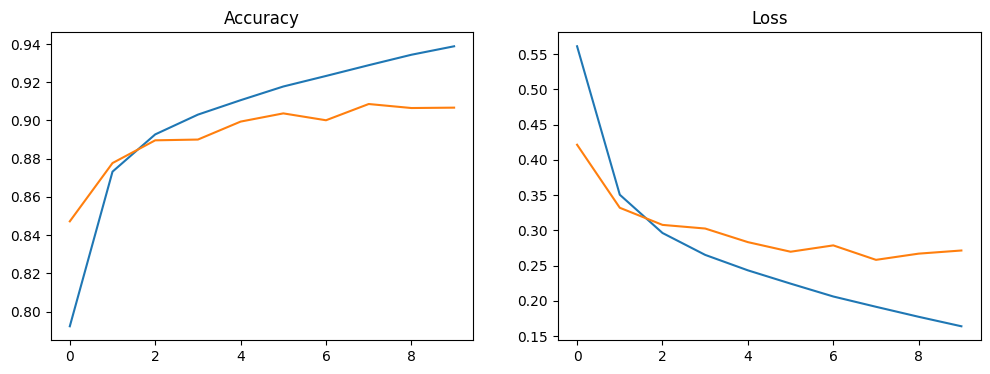

In [6]:
history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test), batch_size=64)

# Loss and Accuracy Curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss')
plt.show()

### 4. Evaluation Metrics (Precision, Recall, F1, MCC, Confusion Matrix)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Classification Report:
               precision    recall  f1-score   support

 T-shirt/top       0.87      0.83      0.85      1000
     Trouser       0.99      0.98      0.98      1000
    Pullover       0.90      0.84      0.87      1000
       Dress       0.92      0.90      0.91      1000
        Coat       0.80      0.92      0.86      1000
      Sandal       0.99      0.97      0.98      1000
       Shirt       0.74      0.73      0.74      1000
     Sneaker       0.96      0.94      0.95      1000
         Bag       0.97      0.98      0.98      1000
  Ankle boot       0.94      0.98      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000

MCC: 0.8964840748625237


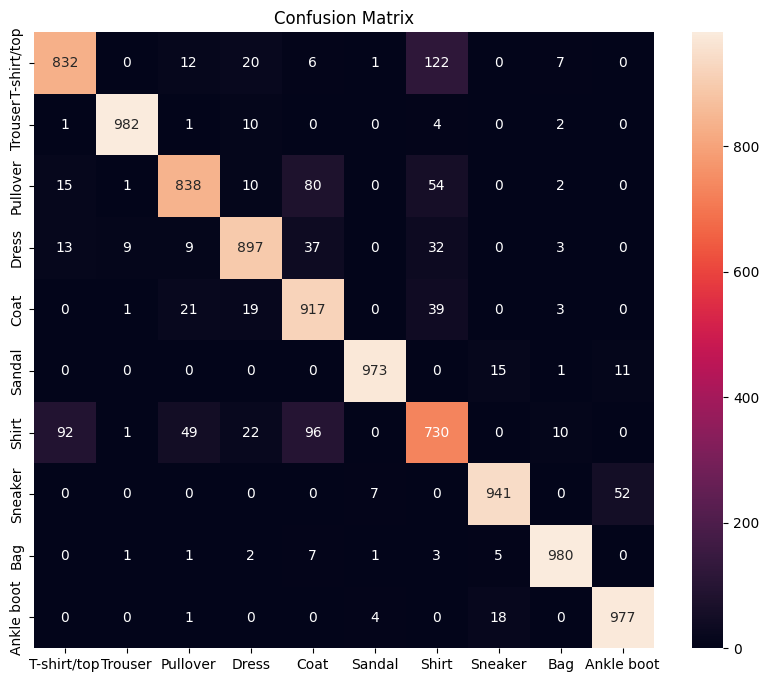

In [7]:
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print("Classification Report:\n", classification_report(y_test, y_pred, target_names=class_names))
print("MCC:", matthews_corrcoef(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.show()

### 5. ROC and Precision-Recall Curves

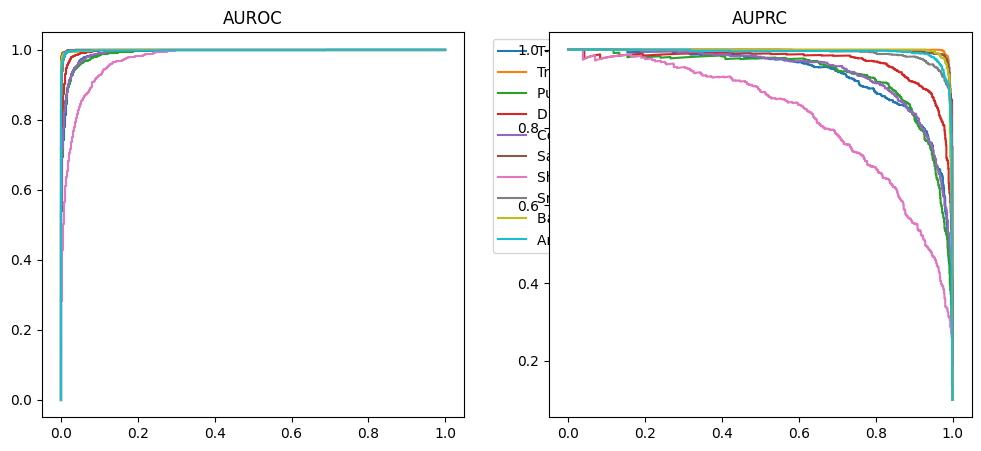

In [8]:
from sklearn.preprocessing import label_binarize
y_test_bin = label_binarize(y_test, classes=[0,1,2,3,4,5,6,7,8,9])

plt.figure(figsize=(12, 5))
# AUROC
plt.subplot(1, 2, 1)
for i in range(10):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_probs[:, i])
    plt.plot(fpr, tpr, label=f'{class_names[i]} (AUC={auc(fpr, tpr):.2f})')
plt.title('AUROC')
plt.legend(bbox_to_anchor=(1.05, 1))

# AUPRC
plt.subplot(1, 2, 2)
for i in range(10):
    p, r, _ = precision_recall_curve(y_test_bin[:, i], y_pred_probs[:, i])
    plt.plot(r, p, label=f'{class_names[i]} (AP={average_precision_score(y_test_bin[:, i], y_pred_probs[:, i]):.2f})')
plt.title('AUPRC')
plt.show()

### 6. Interpretability: Saliency and Heatmaps (Grad-CAM)

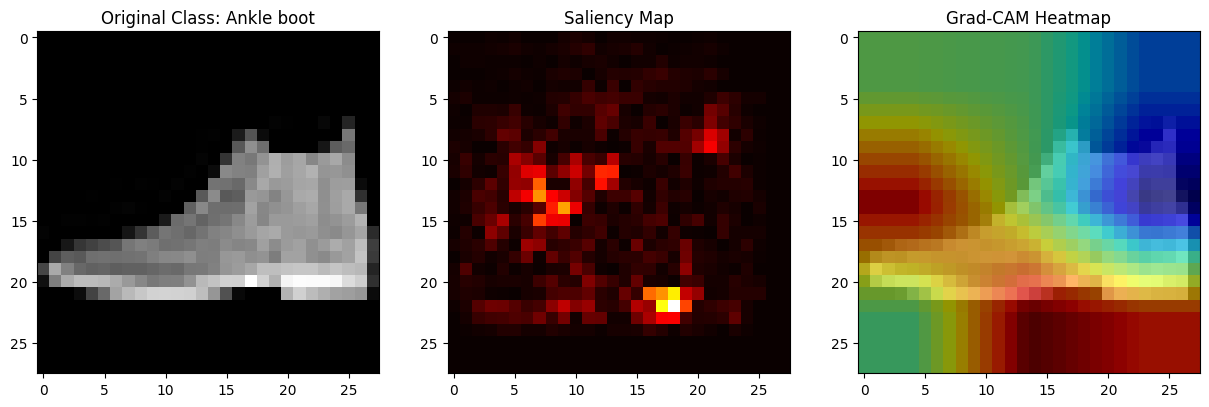

In [14]:
def get_gradcam(img_array, model, last_conv_layer_name, pred_index=None):
    # Re-build a functional sub-model from the original layers
    # This is the most robust way to access internal activations in Keras 3
    inputs = tf.keras.Input(shape=model.input_shape[1:])
    x = inputs

    layer_outputs = {}
    for layer in model.layers:
        x = layer(x)
        layer_outputs[layer.name] = x

    # Target the specific convolution layer and the final output
    grad_model = tf.keras.Model(inputs, [layer_outputs[last_conv_layer_name], x])

    with tf.GradientTape() as tape:
        img_tensor = tf.cast(img_array, tf.float32)
        conv_outputs, predictions = grad_model(img_tensor)

        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    # 1. Get gradients of the top class wrt the output feature map
    grads = tape.gradient(class_channel, conv_outputs)

    # 2. Global Average Pooling of the gradients
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # 3. Weigh the feature map by the pooled gradients
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # 4. Apply ReLU and normalize for visualization
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

# Ensure model is called once to initialize internal states
_ = model(x_test[:1])

# Select an image
idx = 0
img = x_test[idx:idx+1]

# --- Saliency Map ---
img_tensor = tf.convert_to_tensor(img, dtype=tf.float32)
with tf.GradientTape() as tape:
    tape.watch(img_tensor)
    pred = model(img_tensor)
    loss = pred[0, tf.argmax(pred[0])]
grads = tape.gradient(loss, img_tensor)
saliency = tf.reduce_max(tf.abs(grads), axis=-1)[0].numpy()

# --- Grad-CAM Heatmap ---
heatmap = get_gradcam(img, model, 'conv_3')

# --- Visualization ---
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1); plt.imshow(img[0].reshape(28,28), cmap='gray'); plt.title(f'Original Class: {class_names[y_test[idx]]}')
plt.subplot(1, 3, 2); plt.imshow(saliency, cmap='hot'); plt.title('Saliency Map')
plt.subplot(1, 3, 3); plt.imshow(img[0].reshape(28,28), cmap='gray');
plt.imshow(cv2.resize(heatmap, (28, 28)), alpha=0.6, cmap='jet'); plt.title('Grad-CAM Heatmap')
plt.show()